In [ ]:
# ClearML credentials

In [ ]:
! gdown 1fKt7tzfaztBX7SL-yA1zalyzozVFGNwm

In [ ]:
! mkdir unziped/

In [ ]:
! unzip archive.zip -d unziped

In [ ]:
! pip install timm clearml pytorch_lightning lion-pytorch

In [ ]:
import os
from os.path import join

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import timm
import pytorch_lightning as pl

from clearml import Task

# Example:

In [ ]:
transform = A.Compose([
    A.LongestMaxSize(224),
    A.PadIfNeeded(224, 224, border_mode=2),
    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(p=0.5, border_mode=1),
        A.Rotate(45, p=0.5, border_mode=1),
        A.RandomRotate90(p=0.5)
        ], p=0.5),
    A.OneOf([
          A.HueSaturationValue(p=0.5),
          A.RGBShift(p=0.5),
          A.RandomBrightnessContrast(p=0.5),
          A.MotionBlur(p=0.5),
          A.MedianBlur(blur_limit=3, p=0.5),
          A.Blur(blur_limit=3, p=0.5)
        ], p=0.5),
    A.GaussNoise(p=0.5)
])

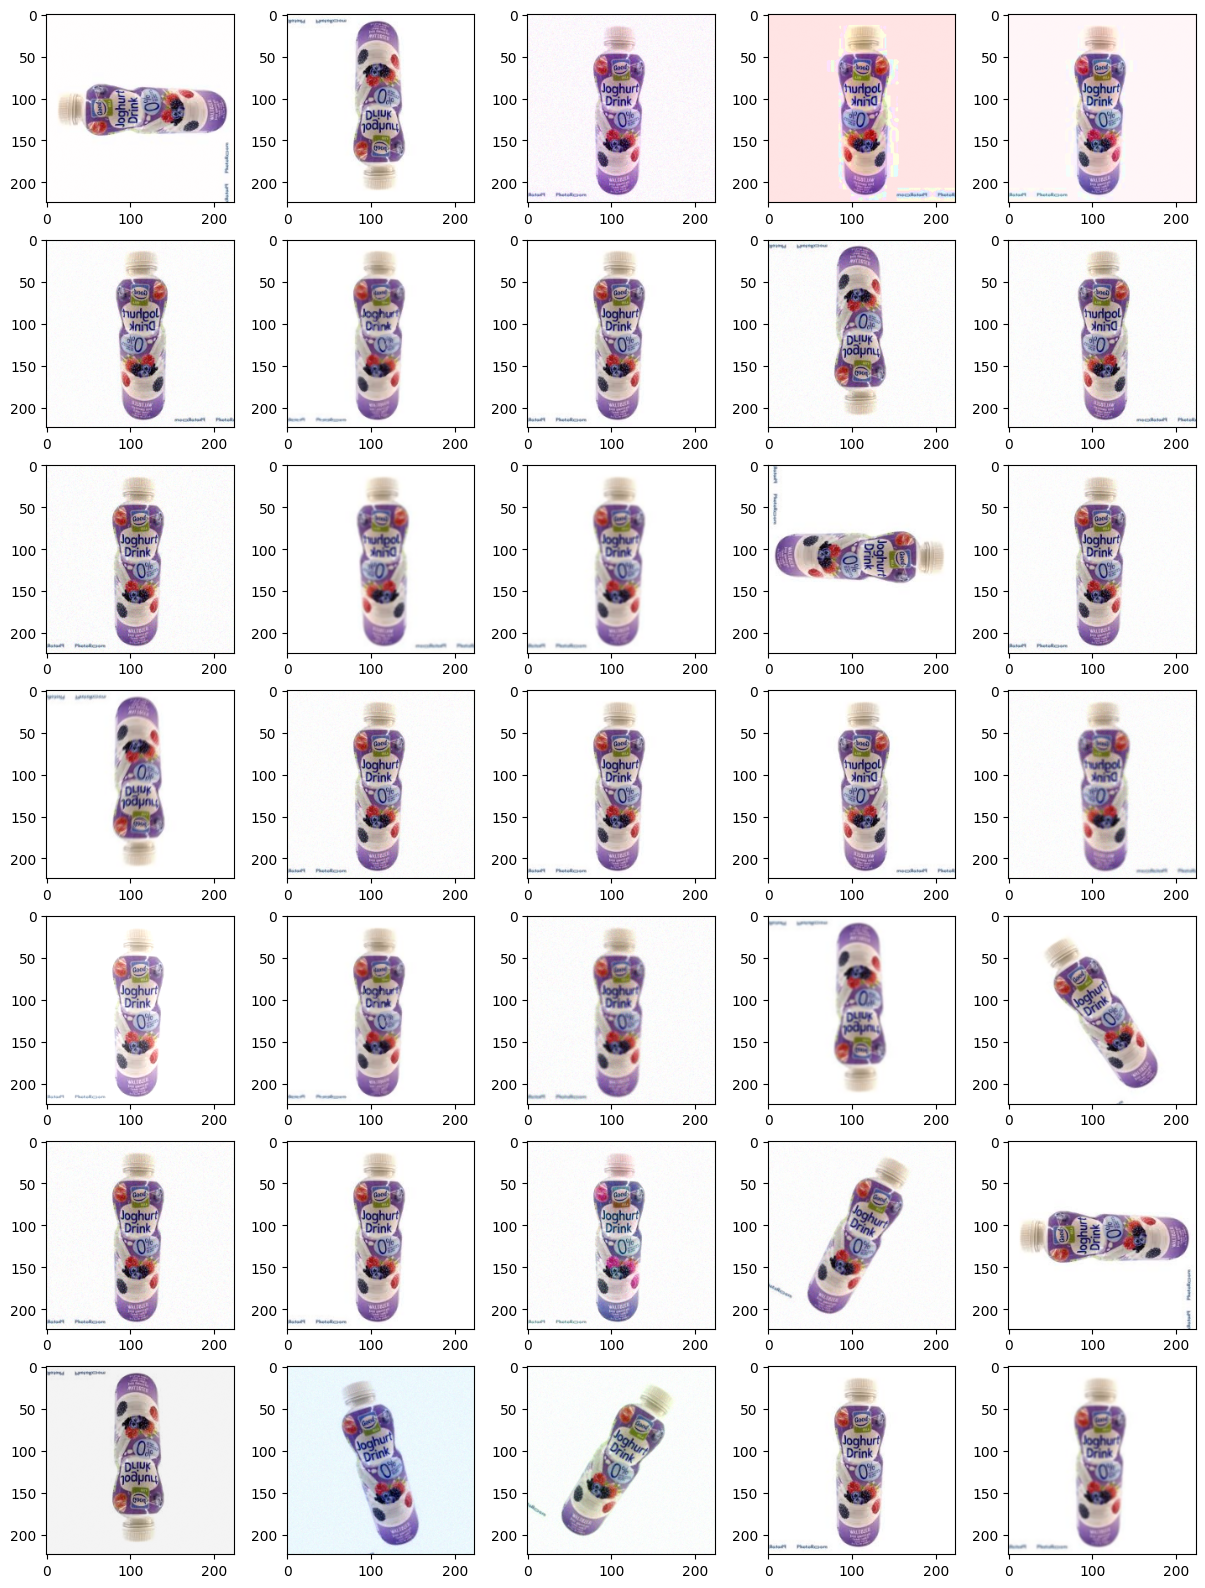

In [ ]:
image = Image.open('garbage_classification/plastic/plastic1.jpg')
image = np.array(image, dtype=np.uint8)

fig, ax = plt.subplots(7, 5, figsize=(15, 20))
for i in range(7):
    for j in range(5):
        img = transform(image=image)['image']
        ax[i, j].imshow(img / 255)

plt.show()

# Preprocessing:

In [ ]:
classes = [
    'battery',
    'cardboard',
    'plastic',
    'metal',
    'paper',
    'biological',
    'brown-glass',
    'green-glass',
    'white-glass'
]

cls_to_idx = {cls: i for cls, i in zip(classes, range(len(classes)))}
cls_to_idx

{'battery': 0,
 'cardboard': 1,
 'plastic': 2,
 'metal': 3,
 'paper': 4,
 'biological': 5,
 'brown-glass': 6,
 'green-glass': 7,
 'white-glass': 8}

In [ ]:
root = 'unziped/garbage_classification'

for cls in classes:
    path = join(root, cls)
    print(f'{cls}: {len(os.listdir(path))}')

battery: 945
cardboard: 891
plastic: 865
metal: 769
paper: 1050
biological: 985
brown-glass: 607
green-glass: 629
white-glass: 775


In [ ]:
root = 'unziped/garbage_classification'
samples = []
labels = []

for cls in classes:
    path = join(root, cls)
    for i, img in enumerate(sorted(os.listdir(path))):
        samples.append(join(path, img))
        labels.append(cls_to_idx[cls])

assert len(samples) == len(labels)

In [ ]:
df = pd.DataFrame({
    'samples': samples,
    'labels': labels
})

In [ ]:
df

,samples,labels
0,unziped/garbage_classification/battery/battery1.jpg,0
1,unziped/garbage_classification/battery/battery10.jpg,0
2,unziped/garbage_classification/battery/battery100.jpg,0
3,unziped/garbage_classification/battery/battery101.jpg,0
4,unziped/garbage_classification/battery/battery102.jpg,0
...,...,...
7511,unziped/garbage_classification/white-glass/white-glass95.jpg,8
7512,unziped/garbage_classification/white-glass/white-glass96.jpg,8
7513,unziped/garbage_classification/white-glass/white-glass97.jpg,8
7514,unziped/garbage_classification/white-glass/white-glass98.jpg,8


In [ ]:
idx_to_cls = {i: cls for cls, i in cls_to_idx.items()}
idx_to_cls

{0: 'battery',
 1: 'cardboard',
 2: 'plastic',
 3: 'metal',
 4: 'paper',
 5: 'biological',
 6: 'brown-glass',
 7: 'green-glass',
 8: 'white-glass'}

In [ ]:
x_train, x_temp, y_train, y_temp = train_test_split(df.samples.to_numpy(), df.labels.to_numpy(),
                                                    test_size=0.2,
                                                    random_state=0,
                                                    shuffle=True,
                                                    stratify=df.labels
                                                    )

x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp,
                                                    test_size=0.5,
                                                    random_state=0,
                                                    shuffle=True,
                                                    stratify=y_temp
                                                    )

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, samples, labels, transform):
        super().__init__()
        self.samples = samples
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path = self.samples[index]
        label = self.labels[index]
        img = Image.open(path)

        if img.mode != 'RGB':
            img = img.convert('RGB')

        img = np.array(img, dtype=np.uint8)
        img = self.transform(image=img)['image']

        return img, label

In [ ]:
RESCALE_SIZE = 224

train_transform = A.Compose([
    A.LongestMaxSize(RESCALE_SIZE),
    A.PadIfNeeded(RESCALE_SIZE, RESCALE_SIZE, border_mode=2),
    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(p=0.5),
        A.Rotate(45, p=0.5),
        A.RandomRotate90(p=0.5)
        ], p=0.5),
    A.OneOf([
          A.HueSaturationValue(p=0.5),
          A.RGBShift(p=0.5),
          A.RandomBrightnessContrast(p=0.5),
          A.MotionBlur(p=0.5),
          A.MedianBlur(blur_limit=3, p=0.5),
          A.Blur(blur_limit=3, p=0.5)
        ], p=0.5),
    A.GaussNoise(p=0.4),
    A.Normalize(),
    ToTensorV2()
])

test_transform = A.Compose([
    A.LongestMaxSize(RESCALE_SIZE),
    A.PadIfNeeded(RESCALE_SIZE, RESCALE_SIZE, border_mode=2),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
train_ds = CustomDataset(
    x_train,
    y_train,
    train_transform
)

val_ds = CustomDataset(
    x_temp,
    y_temp,
    test_transform
)

test_ds = CustomDataset(
    x_test,
    y_test,
    test_transform
)

In [ ]:
train_loader = DataLoader(
    train_ds,
    shuffle=True,
    batch_size=50,
    num_workers=os.cpu_count(),
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=50,
    shuffle=False,
    num_workers=os.cpu_count()
)

test_loader = DataLoader(
    test_ds,
    batch_size=50,
    shuffle=False,
    num_workers=os.cpu_count()
)

# Training:

In [ ]:
class TrainingModule(pl.LightningModule):
    def __init__(self, ext_logger=None, lr=3e-4,  num_classes=len(classes)):
        super().__init__()

        self.model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=num_classes)
        for child in list(self.model.children())[:-1]:
            for param in child.parameters():
                param.requires_grad = False

        self.loss = nn.CrossEntropyLoss()
        self.lr = lr
        self.ext_logger = ext_logger
        self.train_loss = []
        self.val_loss = []
        self.predictions = []
        self.targets = []

    def forward(self, x):
        output = self.model(x)

        return output

    def training_step(self, batch, batch_idx):
        """The full training loop"""
        x, y = batch

        outputs = self.model(x)
        loss = self.loss(outputs, y)
        self.train_loss.append(loss.detach())

        return loss

    def validation_step(self, batch, batch_idx):
        """the full validation loop"""
        x, y = batch

        outputs = self.model(x)
        loss = self.loss(outputs, y)
        self.val_loss.append(loss.detach())

        outputs = outputs.argmax(dim=1)
        self.predictions.extend(outputs)
        self.targets.extend(y)

    def configure_optimizers(self):
        """Define optimizers and LR schedulers."""
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.lr)

        lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
        lr_dict = {
            "scheduler": lr_scheduler,
            "interval": "epoch",
            "frequency": 1,
        }

        return [optimizer], [lr_dict]

    def on_train_epoch_end(self):
        avg_train_loss = torch.tensor(self.train_loss).mean()
        if self.ext_logger is not None:
            self.ext_logger.report_scalar(title='Train/Validation Loss', series='Train loss', iteration=self.current_epoch, value=avg_train_loss)

        self.train_loss.clear()

    def on_validation_epoch_end(self):
        avg_val_loss = torch.tensor(self.val_loss).mean()
        preds, targets = torch.tensor(self.predictions).numpy(), torch.tensor(self.targets).numpy()
        acc = accuracy_score(targets, preds)
        prec = precision_score(targets, preds, average='macro')
        rec = recall_score(targets, preds, average='macro')
        f1 = f1_score(targets, preds, average='macro')
        if self.ext_logger is not None:
            self.ext_logger.report_scalar(title='Train/Validation Loss', series='Validation loss', iteration=self.current_epoch, value=avg_val_loss)
            self.ext_logger.report_scalar(title='Metrics', series='Accuracy', iteration=self.current_epoch, value=acc)
            self.ext_logger.report_scalar(title='Metrics', series='Precision', iteration=self.current_epoch, value=prec)
            self.ext_logger.report_scalar(title='Metrics', series='Recall', iteration=self.current_epoch, value=rec)
            self.ext_logger.report_scalar(title='Metrics', series='F1Score', iteration=self.current_epoch, value=f1)

        self.val_loss.clear()
        self.predictions.clear()
        self.targets.clear()

        torch.save(self.model.state_dict(), f'SmartSort_{self.current_epoch}.pt')

        if self.current_epoch == 0:
            for param in self.model.parameters():
                param.requires_grad = True

In [ ]:
lr = 3e-4
num_epochs = 20

# инициализация эксперимента
task = Task.init(
    project_name='TrashClassification',
    task_name=f'EB4_Adamw_{lr}'
)

logger = task.get_logger()

# гиперпараметры для логирования
parameters = {'optimizer': 'AdamW',
              'lr': lr,
              'num_epochs': num_epochs,
              }

task.connect(parameters)

In [ ]:
model = TrainingModule(lr=lr, ext_logger=logger)

trainer = pl.Trainer(
    accelerator='gpu',
    devices=1,
    max_epochs=num_epochs,
    logger=False
)

In [ ]:
trainer.fit(model, train_loader, val_loader)

In [ ]:
model = timm.create_model('efficientnet_b4', num_classes=len(classes))
model.load_state_dict(torch.load('SmartSort_15.pt'))
model.eval()

In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

def test_model(model, test_loader):
    preds = []
    targets = []

    model.eval()
    model = model.to(device)
    with torch.no_grad():
        for samples, labels in test_loader:
            samples = samples.to(device)

            res = model(samples)
            res = res.detach().argmax(dim=1)
            preds.extend(res)
            targets.extend(labels)

    preds = torch.tensor(preds).numpy()
    targets = torch.tensor(targets).numpy()
    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, average='macro')
    rec = recall_score(targets, preds, average='macro')
    f1 = f1_score(targets, preds, average='macro')
    model = model.to('cpu')

    return acc, prec, rec, f1

acc, prec, rec, f1 = test_model(model, test_loader)

print(
    f"""
      Accuracy: {acc}
      Precision: {prec}
      Recall: {rec},
      F1-measure: {f1}
      """
    )


      Accuracy: 0.9707446808510638
      Precision: 0.9706695861152819
      Recall: 0.9705102151501307,
      F1-measure: 0.9704444731367486
      


In [ ]:
parameters = {'Test accuracy': acc,
              'Test precision': prec,
              'Test recall': rec,
              'Test F1-measure': f1
              }

task.connect(parameters)

{'Test accuracy': 0.9707446808510638,
 'Test precision': 0.9706695861152819,
 'Test recall': 0.9705102151501307,
 'Test F1-measure': 0.9704444731367486}

In [ ]:
task.close()

# Exporting to ONNX:

In [ ]:
! pip install onnx onnxruntime

In [ ]:
import onnxruntime

In [ ]:
model = timm.create_model('efficientnet_b4', num_classes=len(classes))
model.load_state_dict(torch.load('SmartSort_15.pt'))
model.eval()

In [ ]:
# Input to the model
x = torch.randn(1, 3, 224, 224, requires_grad=True)
torch_out = model(x)

# Export the model
torch.onnx.export(model,               # model being run
                  x,                         # model input (or a tuple for multiple inputs)
                  f"SmartSort_eb4.onnx",   # where to save the model (can be a file or file-like object)
                  export_params=True,        # store the trained parameter weights inside the model file
                  opset_version=10,          # the ONNX version to export the model to
                  do_constant_folding=True,  # whether to execute constant folding for optimization
                  input_names = ['input'],   # the model's input names
                  output_names = ['output'], # the model's output names
                  dynamic_axes={'input' : {0 : 'batch_size'},    # variable length axes
                                'output' : {0 : 'batch_size'}})

In [ ]:
ort_session = onnxruntime.InferenceSession("SmartSort_eb4.onnx", providers=["CPUExecutionProvider"])

# compute ONNX Runtime output prediction
ort_inputs = {'input': x.detach().numpy()}
ort_outs = ort_session.run(None, ort_inputs)

# compare ONNX Runtime and PyTorch results
np.testing.assert_allclose(torch_out.detach().cpu().numpy(), ort_outs[0], rtol=1e-03, atol=1e-05)

print("Exported model has been tested with ONNXRuntime, and the result looks good!")

Exported model has been tested with ONNXRuntime, and the result looks good!
